In [1]:
# --- Setup: add project root to sys.path so that src is discoverable ---
import sys
from pathlib import Path
project_root = Path.cwd().parent  # assuming current working directory is 'notebook'
sys.path.insert(0, str(project_root))

# --- Imports from our modules ---
from src.config.loaders import load_config, load_station_data
from src.data.engineering import engineer_data
from src.data.scaling import scale_df, inverse_scale
from src.data.windowing import data_to_X_y
from src.visualization.plotting import plot_loss, plot_predictions

from src.models.lstm import build_simple_lstm_model, build_optimized_lstm_model
from src.models.cnn import build_cnn_model

# --- Standard Setup ---
import matplotlib.pyplot as plt
import os
import tensorflow as tf
import numpy as np
import pandas as pd

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = False
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
# --- Load configuration ---
cfg = load_config()

model_builders = {
    "Simple LSTM": build_simple_lstm_model,
    "Optimized LSTM": build_optimized_lstm_model,
    "CNN": build_cnn_model
}

In [3]:
# --- Load and preprocess data ---
station_data = load_station_data(cfg)
for station in station_data:
    print(f"Engineering features for {station} ...")
    station_data[station] = engineer_data(station_data[station])

# For forecasting, choose Station1 (for example)
df_forecast = station_data["Station1"]
scaled_df, scaler = scale_df(df_forecast)

Loaded data from 6 stations: ['Station1', 'Station2', 'Station3', 'Station4', 'Station5', 'Station6']
Engineering features for Station1 ...
Engineering features for Station2 ...
Engineering features for Station3 ...
Engineering features for Station4 ...
Engineering features for Station5 ...
Engineering features for Station6 ...


In [4]:
# --- Create Sliding Windows ---
TARGET_COLUMN = cfg["model"]["target_column"]  # "SWC_20"
WINDOW_SIZE = cfg["model"]["window_size"]         # 72
OFFSET = cfg["model"].get("offset", 24)             # 24
X, y = data_to_X_y(scaled_df[TARGET_COLUMN], WINDOW_SIZE, OFFSET)
print("Full sliding windows shapes: X =", X.shape, ", y =", y.shape)

Full sliding windows shapes: X = (52464, 72, 1) , y = (52464,)


In [5]:
# Split into training (70%), validation (20%), test (10%)
n = len(X)
X_train, y_train = X[:int(n*0.7)], y[:int(n*0.7)]
X_val, y_val = X[int(n*0.7):int(n*0.9)], y[int(n*0.7):int(n*0.9)]
X_test, y_test = X[int(n*0.9):], y[int(n*0.9):]
print("Split shapes -- X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)


Split shapes -- X_train: (36724, 72, 1) X_val: (10493, 72, 1) X_test: (5247, 72, 1)


In [6]:
# --- Build and Train Model ---
model = build_simple_lstm_model(WINDOW_SIZE)
checkpoint_path = "model1.keras"
cp = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss', mode='min')
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, mode='min')
EPOCHS = cfg["lstm"]["epochs"]
BATCH_SIZE = cfg["lstm"]["batch_size"]
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    callbacks=[cp, early_stopping])

Epoch 1/10


c:\Users\chris\miniconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


1148/1148 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 0.1026 - root_mean_squared_error: 0.2973 - val_loss: 0.0037 - val_root_mean_squared_error: 0.0606
Epoch 2/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0045 - root_mean_squared_error: 0.0674 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0591
Epoch 3/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0043 - root_mean_squared_error: 0.0659 - val_loss: 0.0033 - val_root_mean_squared_error: 0.0578
Epoch 4/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 0.0042 - root_mean_squared_error: 0.0649 - val_loss: 0.0032 - val_root_mean_squared_error: 0.0569
Epoch 5/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 0.0041 - root_mean_squared_error: 0.0638 - val_loss: 0.0032 - val_root_mean_squared_error: 0.0564
Epoch 6/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 0.0038 - root_mean_squared_error: 0.0617 - val_loss: 0.0031 - val_root_mean_squared_error: 0.0560
Epoch 7/10
1148/1148 ━━━━━━━━━━━━━━━━━━

In [7]:
# --- Reload Best Model and Generate Predictions ---
model = tf.keras.models.load_model(checkpoint_path)
predictions_scaled = model.predict(X_test).flatten()

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [8]:
preds_inv_df = inverse_scale(predictions_scaled, scaled_df, TARGET_COLUMN)
predictions_rescaled = preds_inv_df[TARGET_COLUMN].values

actual_inv_df = inverse_scale(y_test.reshape(-1, 1), scaled_df, TARGET_COLUMN)
y_actual = actual_inv_df[TARGET_COLUMN].values
print("First 5 rescaled predictions:", predictions_rescaled[:5])

First 5 rescaled predictions: [0.79970348 0.80428028 0.80617827 0.80693495 0.80571043]


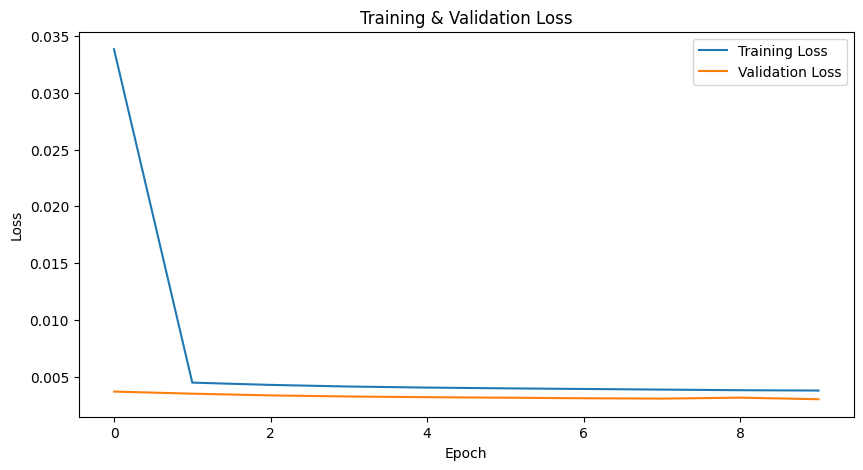

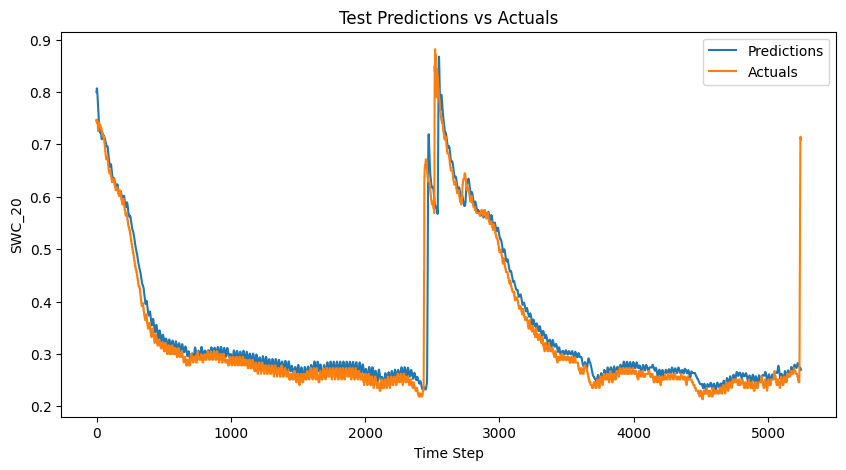

R2 Score: 0.9082895401186352
Mean Squared Error: 0.0017733176532125142
Mean Absolute Error: 0.01884229218239303
Mean Absolute Percentage Error: 0.053789099367574526


In [9]:
# --- Plot Loss and Predictions ---
plot_loss(history)
plot_predictions(y_actual, predictions_rescaled, TARGET_COLUMN)

# --- Print Evaluation Metrics ---
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
print("R2 Score:", r2_score(y_actual, predictions_rescaled))
print("Mean Squared Error:", mean_squared_error(y_actual, predictions_rescaled))
print("Mean Absolute Error:", mean_absolute_error(y_actual, predictions_rescaled))
print("Mean Absolute Percentage Error:", mean_absolute_percentage_error(y_actual, predictions_rescaled))

Training model: Simple LSTM


c:\Users\chris\miniconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


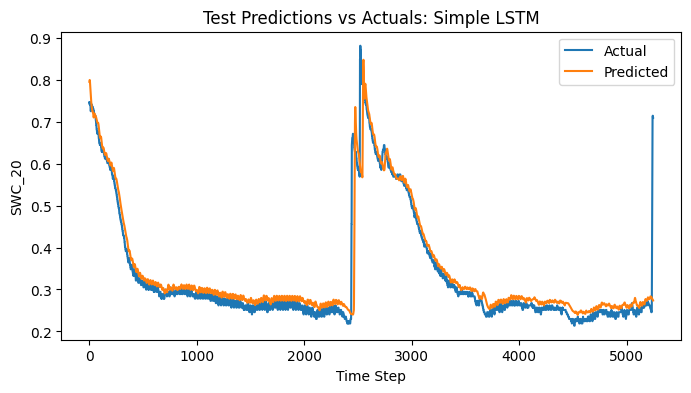

Training model: Optimized LSTM


c:\Users\chris\miniconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


164/164 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


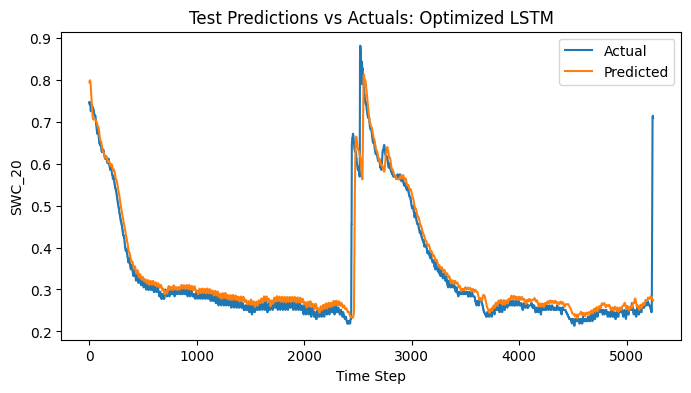

Training model: CNN


c:\Users\chris\miniconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


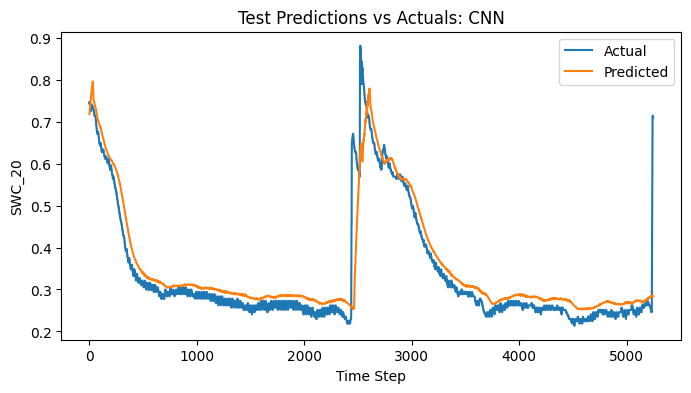

Model Performance Comparison:
            Model        R2       MSE       MAE      MAPE
0     Simple LSTM  0.906443  0.001809  0.020921  0.062539
1  Optimized LSTM  0.906573  0.001807  0.019413  0.056221
2             CNN  0.870313  0.002508  0.031269  0.093307


In [10]:
# Initialize an empty list to store performance results for each model.
results = []

# Loop over each model builder.
for model_name, builder in model_builders.items():
    print(f"Training model: {model_name}")
    # Build the model with the given window size.
    model = builder(WINDOW_SIZE)
    
    # Define a unique checkpoint path for each model (so they don't overwrite one another)
    cp_path = f"{model_name.replace(' ', '_')}_model.keras"
    cp = tf.keras.callbacks.ModelCheckpoint(cp_path, save_best_only=True, monitor='val_loss', mode='min')
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, mode='min')
    
    # Train the model (set verbose=0 for quieter output)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=cfg["lstm"]["epochs"],
        batch_size=cfg["lstm"]["batch_size"],
        callbacks=[cp, early_stopping],
        verbose=0
    )
    
    # Reload the best model
    model = tf.keras.models.load_model(cp_path)
    
    # Generate predictions on the test set and flatten them
    predictions_scaled = model.predict(X_test).flatten()
    
    # Inverse-scale the predictions (using your inverse_scale function)
    preds_inv_df = inverse_scale(predictions_scaled, scaled_df, TARGET_COLUMN)
    predictions_rescaled = preds_inv_df[TARGET_COLUMN].values
    
    # Inverse-scale the actual test target values
    actual_inv_df = inverse_scale(y_test.reshape(-1, 1), scaled_df, TARGET_COLUMN)
    y_actual = actual_inv_df[TARGET_COLUMN].values
    
    # Compute evaluation metrics
    r2 = r2_score(y_actual, predictions_rescaled)
    mse = mean_squared_error(y_actual, predictions_rescaled)
    mae = mean_absolute_error(y_actual, predictions_rescaled)
    mape = mean_absolute_percentage_error(y_actual, predictions_rescaled)
    
    # Append the metrics in a dictionary to our results list
    results.append({
        "Model": model_name,
        "R2": r2,
        "MSE": mse,
        "MAE": mae,
        "MAPE": mape
    })
    
    # Plot predictions vs. actual for this model
    plt.figure(figsize=(8, 4))
    plt.plot(y_actual, label='Actual')
    plt.plot(predictions_rescaled, label='Predicted')
    plt.title(f"Test Predictions vs Actuals: {model_name}")
    plt.xlabel("Time Step")
    plt.ylabel(TARGET_COLUMN)
    plt.legend()
    plt.show()

# Create a DataFrame from the results list and print it.
results_df = pd.DataFrame(results)
print("Model Performance Comparison:")
print(results_df)